In [ ]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal
from langchain_openai import ChatOpenAI


In [3]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    equation: str
    descriminant: float
    result: str

In [5]:
def show_equation(state: QuadState):
    equation = f"{state.get("a")}x2+{state.get("b")}x+{state.get("c")}"
    return {"equation": equation}

def calculate_descriminant(state: QuadState):
    descriminant = (state.get("b")**2)-(2*state.get("a")*state.get("c"))
    return {"descriminant": descriminant}

In [10]:
def real_roots(state: QuadState):
    root1 = (-state.get("b") + state.get("descriminant")**0.5) / (2*state.get("a"))
    root2 = (-state.get("b") - state.get("descriminant")**0.5) / (2*state.get("a"))

    return {"result":f"The roots are {root1} and {root2}"}

def repeated_roots(state: QuadState):
    root = -state.get("b")/(2*state.get("a"))
    return {"result":f"Only repeating root is {root}"}

def no_real_roots(state: QuadState):

    return {"result":f"No real roots"}


In [11]:
def check_condition(state: QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:
    if state.get("descriminant") > 0:
        return "real_roots"
    elif state.get("descriminant") == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [14]:
graph = StateGraph(QuadState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_descriminant",calculate_descriminant)

graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("no_real_roots",no_real_roots)


graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_descriminant")
graph.add_conditional_edges("calculate_descriminant",check_condition)

graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_real_roots",END)


workflow = graph.compile()


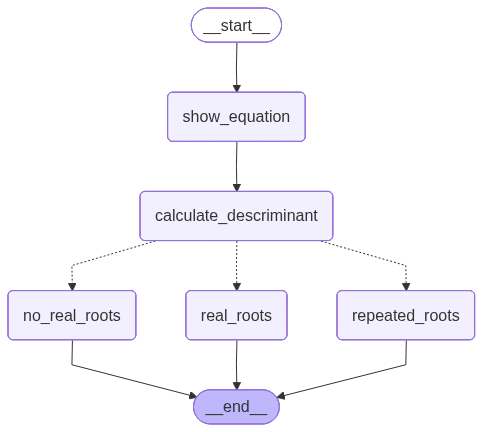

In [15]:
workflow

In [19]:
initial_state = {"a": 4,"b":-5,"c":-4}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2+-5x+-4', 'descriminant': 57, 'result': 'The roots are 1.5687293044088437 and -0.3187293044088437'}
